In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv(r'C:\Users\HP\Desktop\Python\Vs_Python\Projects\Diabetes_prediction\Dataset\clean_dataset.csv')

In [13]:
df.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,0,33.6,0.627,50,1
1,1,85,0,26.6,0.351,31,0
2,8,183,0,23.3,0.672,32,1
3,1,89,94,28.1,0.167,21,0
4,0,137,168,43.1,2.288,33,1


In [3]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=8, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}


In [7]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    results = {}

    for name, model in models.items():
        # Pipeline: PowerTransformer -> StandardScaler -> Model
        pipe = Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        # Fit the model
        pipe.fit(X_train, y_train)

        # Predictions
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        cm = confusion_matrix(y_test, y_test_pred)

        # Check for over/underfitting
        if abs(train_acc - test_acc) > 0.1:
            if train_acc > test_acc:
                fit_status = "Overfitting"
            else:
                fit_status = "Underfitting"
        else:
            fit_status = "Good Fit"

        # Save results
        results[name] = {
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'MSE': mse,
            'Fit Status': fit_status,
            'Confusion Matrix': cm
        }

    return results


In [8]:
results = evaluate_models(X_train, X_test, y_train, y_test, models)


In [9]:
for model_name, metrics in results.items():
    print(f"\n===== {model_name} =====")
    print(f"Train Accuracy: {metrics['Train Accuracy']:.3f}")
    print(f"Test Accuracy : {metrics['Test Accuracy']:.3f}")
    print(f"MSE           : {metrics['MSE']:.3f}")
    print(f"Fit Status    : {metrics['Fit Status']}")
    print("Confusion Matrix:")
    print(metrics['Confusion Matrix'])



===== Logistic Regression =====
Train Accuracy: 0.776
Test Accuracy : 0.752
MSE           : 0.248
Fit Status    : Good Fit
Confusion Matrix:
[[140  28]
 [ 35  51]]

===== Decision Tree =====
Train Accuracy: 0.825
Test Accuracy : 0.752
MSE           : 0.248
Fit Status    : Good Fit
Confusion Matrix:
[[141  27]
 [ 36  50]]

===== Random Forest =====
Train Accuracy: 0.901
Test Accuracy : 0.756
MSE           : 0.244
Fit Status    : Overfitting
Confusion Matrix:
[[139  29]
 [ 33  53]]

===== SVM =====
Train Accuracy: 0.800
Test Accuracy : 0.756
MSE           : 0.244
Fit Status    : Good Fit
Confusion Matrix:
[[143  25]
 [ 37  49]]

===== KNN =====
Train Accuracy: 0.817
Test Accuracy : 0.748
MSE           : 0.252
Fit Status    : Good Fit
Confusion Matrix:
[[138  30]
 [ 34  52]]


In [10]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'clf__max_depth': [3, 5, 7, None],
        'clf__min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 8, None],
        'clf__min_samples_split': [2, 5, 10]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    }
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

def evaluate_with_gridsearch(X_train, X_test, y_train, y_test, models, param_grids):
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Running GridSearch for {name}...")
        pipe = Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        grid = GridSearchCV(pipe, param_grids[name], cv=5, n_jobs=-1, scoring='accuracy')
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        cm = confusion_matrix(y_test, y_test_pred)

        # Fit status
        if abs(train_acc - test_acc) > 0.1:
            fit_status = "Overfitting" if train_acc > test_acc else "Underfitting"
        else:
            fit_status = "Good Fit"

        results[name] = {
            'Best Params': grid.best_params_,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'MSE': mse,
            'Fit Status': fit_status,
            'Confusion Matrix': cm
        }

    return results

# -------------------------------
# 4️⃣ Run Evaluation
# -------------------------------
results = evaluate_with_gridsearch(X_train, X_test, y_train, y_test, models, param_grids)

# -------------------------------
# 5️⃣ Display Results
# -------------------------------
for model_name, metrics in results.items():
    print(f"\n===== {model_name} =====")
    print(f"Best Params    : {metrics['Best Params']}")
    print(f"Train Accuracy : {metrics['Train Accuracy']:.3f}")
    print(f"Test Accuracy  : {metrics['Test Accuracy']:.3f}")
    print(f"MSE            : {metrics['MSE']:.3f}")
    print(f"Fit Status     : {metrics['Fit Status']}")
    print("Confusion Matrix:")
    print(metrics['Confusion Matrix'])



🔹 Running GridSearch for Logistic Regression...

🔹 Running GridSearch for Decision Tree...

🔹 Running GridSearch for Random Forest...

🔹 Running GridSearch for SVM...

🔹 Running GridSearch for KNN...

===== Logistic Regression =====
Best Params    : {'clf__C': 0.1, 'clf__solver': 'liblinear'}
Train Accuracy : 0.778
Test Accuracy  : 0.748
MSE            : 0.252
Fit Status     : Good Fit
Confusion Matrix:
[[138  30]
 [ 34  52]]

===== Decision Tree =====
Best Params    : {'clf__max_depth': 5, 'clf__min_samples_split': 2}
Train Accuracy : 0.839
Test Accuracy  : 0.752
MSE            : 0.248
Fit Status     : Good Fit
Confusion Matrix:
[[139  29]
 [ 34  52]]

===== Random Forest =====
Best Params    : {'clf__max_depth': 8, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Train Accuracy : 0.969
Test Accuracy  : 0.744
MSE            : 0.256
Fit Status     : Overfitting
Confusion Matrix:
[[136  32]
 [ 33  53]]

===== SVM =====
Best Params    : {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf_

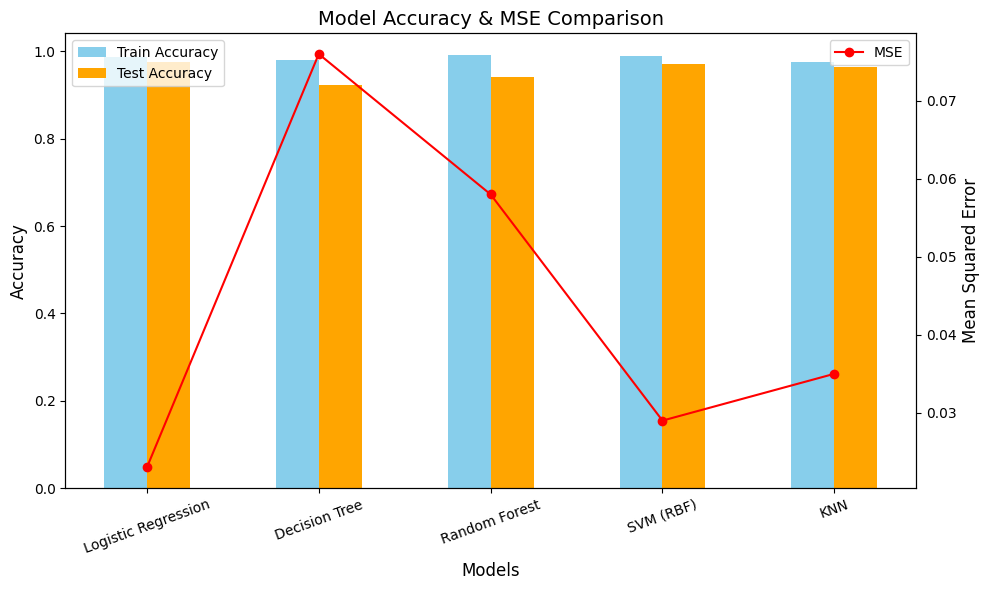

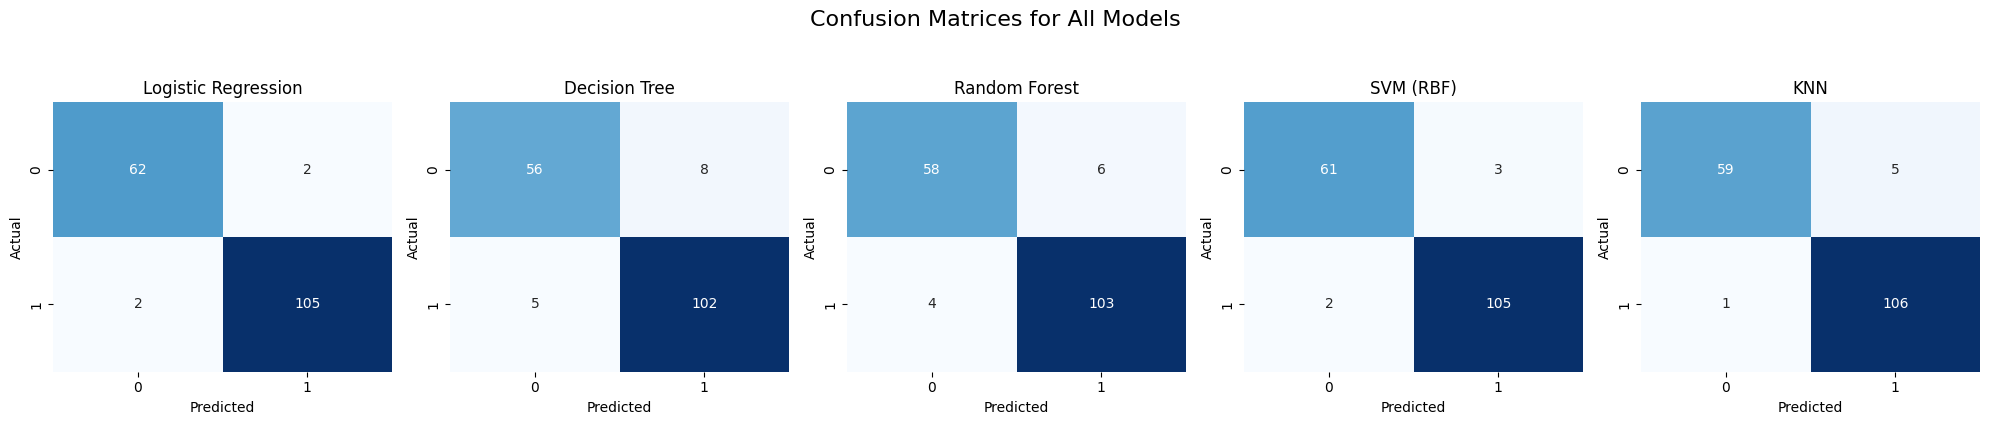

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Model Names and Metrics
# -----------------------------
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM (RBF)', 'KNN']

train_acc = [0.987, 0.980, 0.992, 0.990, 0.977]
test_acc  = [0.977, 0.924, 0.942, 0.971, 0.965]
mse       = [0.023, 0.076, 0.058, 0.029, 0.035]

# Confusion Matrices (from your data)
conf_matrices = [
    np.array([[62, 2], [2, 105]]),   # Logistic Regression
    np.array([[56, 8], [5, 102]]),   # Decision Tree
    np.array([[58, 6], [4, 103]]),   # Random Forest
    np.array([[61, 3], [2, 105]]),   # SVM
    np.array([[59, 5], [1, 106]])    # KNN
]

# -----------------------------
# Plot Accuracy + MSE Comparison
# -----------------------------
x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(x - width/2, train_acc, width, label='Train Accuracy', color='skyblue')
ax1.bar(x + width/2, test_acc, width, label='Test Accuracy', color='orange')
ax1.set_xlabel('Models', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy & MSE Comparison', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20)
ax1.legend(loc='upper left')

# Plot MSE on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, mse, color='red', marker='o', label='MSE')
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# -----------------------------
# Plot Confusion Matrices
# -----------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (model, cm) in enumerate(zip(models, conf_matrices)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(model)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


In [12]:
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Recreate and refit the pipeline with best params found
best_params = {'clf__C': 0.1, 'clf__solver': 'lbfgs'}

# Create pipeline
pipe = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Update pipeline parameters
pipe.set_params(**best_params)

# Fit pipeline on full training data
pipe.fit(X_train, y_train)

# Save model to pickle file
with open('best_logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

print("\n✅ Logistic Regression model saved successfully as 'best_logistic_regression_model.pkl'")



✅ Logistic Regression model saved successfully as 'best_logistic_regression_model.pkl'
